In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from torchvision import datasets
from torchvision.transforms import ToTensor

## Load images

In [2]:
train_data = datasets.MNIST(
    root = 'mnist_data',
    train = True,                         
    transform = ToTensor(), 
    download = True,            
)
test_data = datasets.MNIST(
    root = 'mnist_data', 
    train = False, 
    transform = ToTensor()
)

X_train = train_data.data.view((-1, 28*28)).float() / 255.0
X_test = test_data.data.view((-1, 28*28)).float() / 255.0

y_train = train_data.targets
y_test = test_data.targets

## Define the model

Here the model is defined as a class that inherits from `nn.Module`.
The layers are created in `__init__`, and the forward pass is written
explicitly in the `forward` method using functional calls like `F.relu`.

This is the most common pattern in PyTorch — it gives full control
over the forward pass while still letting PyTorch track all parameters.

In [3]:
torch.manual_seed(12345)

class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(784, 256)
        self.output = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.hidden(x))
        x = self.output(x)
        return x

model = MNISTModel()

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

## Train the network using the backpropagation algorithm

In [4]:
m = 64  # Batch size
g = torch.Generator().manual_seed(12345)

In [5]:
# Training
n_epochs = 213
for epoch in range(n_epochs):

    # Shuffle the training set at the start of each epoch
    perm = torch.randperm(len(X_train), generator=g)

    for i in range(len(X_train) // m):
        ix = perm[i*m : (i+1)*m]
        X = X_train[ix]
        y = y_train[ix]

        # Forward pass
        logits = model(X)
        loss = loss_fn(logits, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 20 == 0:
        print(f"epoch = {epoch:3},  loss = {loss:.4}")

epoch =   0,  loss = 0.6224
epoch =  20,  loss = 0.2072
epoch =  40,  loss = 0.1044
epoch =  60,  loss = 0.06292
epoch =  80,  loss = 0.2032
epoch = 100,  loss = 0.08815
epoch = 120,  loss = 0.08875
epoch = 140,  loss = 0.01326
epoch = 160,  loss = 0.01351
epoch = 180,  loss = 0.01884
epoch = 200,  loss = 0.01561


## Calculate predictions

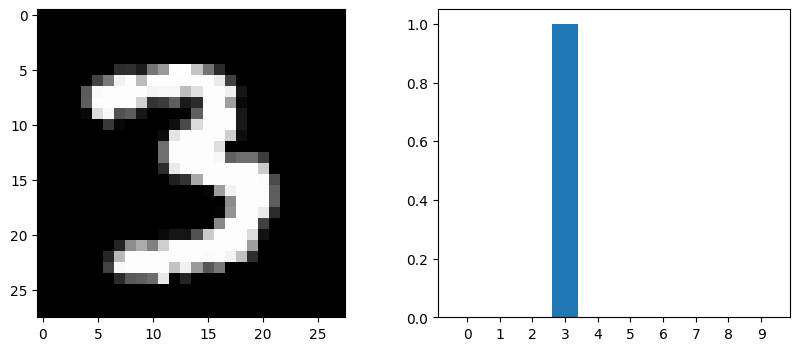

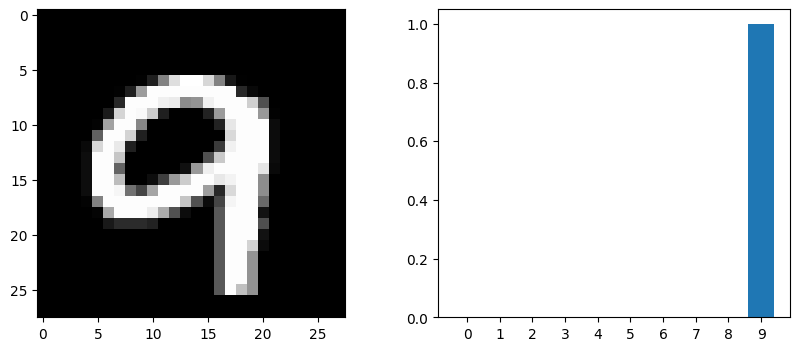

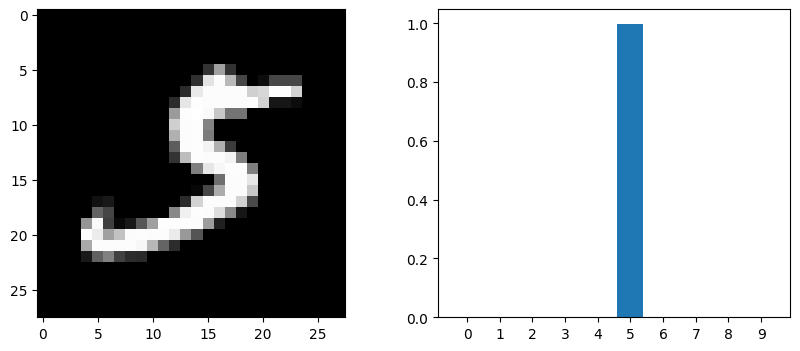

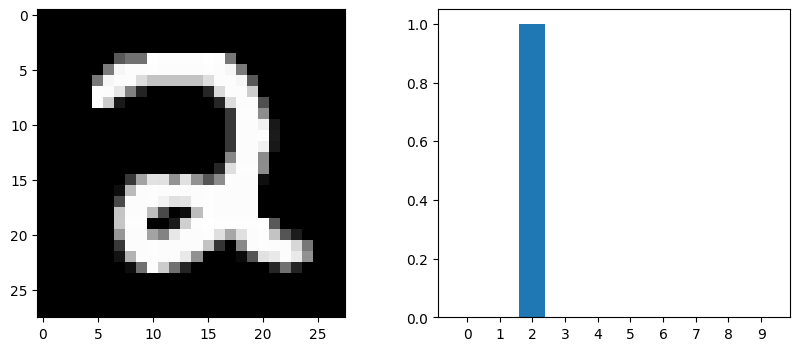

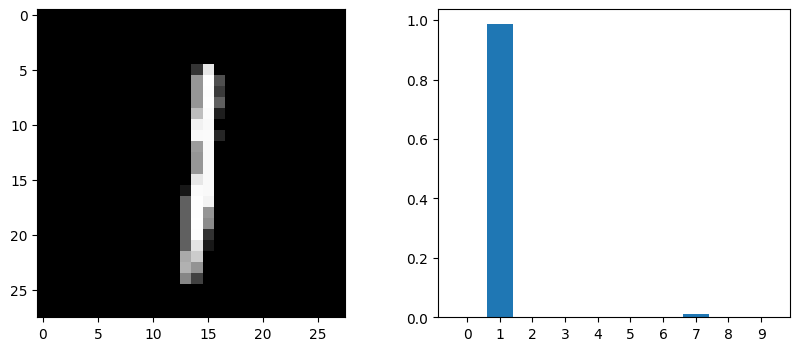

In [6]:
start = 500
for k in range(5):
    X = X_test[start+k]
    
    # Get probabilities using softmax on the model's raw output
    probs = torch.softmax(model(X), dim=0)

    plt.figure(figsize=(10, 4))
    plt.subplot(1,2,1)
    plt.imshow(X.view(28, 28), cmap='gray')
    ind = np.arange(0, 10)
    plt.subplot(1,2,2)
    plt.bar(ind, probs.detach().numpy().flatten())
    plt.xticks(range(10))

## Calculate accuracy

In [7]:
with torch.no_grad():
    logits = model(X_test)
    Y_hat = logits.argmax(dim=1)
    print(f"Accuracy = {(Y_hat == y_test).sum()/len(y_test):.4}")

Accuracy = 0.9815
